# 🎬 Collaborative Filtering — MovieLens 1M
**Dataset:** [MovieLens 1M](https://grouplens.org/datasets/movielens/1m/)  
**Models:** BaselineOnly (ALS bias optimisation) · SVD default · SVD tuned  
**Goal:** Predict movie ratings · Find similar movies (item-based similarity)

---
## Notebook Structure
1. Imports & Setup  
2. Load Data  
3. Exploratory Data Analysis  
4. Build Surprise Dataset  
5. Train / Test Split  
6. Model 1 — BaselineOnly (ALS bias optimisation)  
7. Model 2 — SVD Baseline  
8. Model 3 — SVD Tuned (GridSearchCV)  
9. Model Comparison  
10. Item-Based Movie Similarity  
11. Save Models  
12. Conclusion & Next Steps  

# 1. Imports & Setup

In [1]:
# pip install scikit-surprise joblib pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os

from sklearn.metrics.pairwise import cosine_similarity

from surprise import Reader, Dataset, BaselineOnly, SVD, accuracy
from surprise.model_selection import cross_validate, GridSearchCV, train_test_split

os.makedirs('model', exist_ok=True)

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_palette('husl')

# 2. Load Data

In [2]:
ratings = pd.read_csv('data/ratings.csv')
movies  = pd.read_csv('data/movies.csv')
users   = pd.read_csv('data/users.csv')

display(ratings.head(3))
display(movies.head(3))
display(users.head(3))

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117


# 3. Exploratory Data Analysis

In [3]:
n_users   = ratings['user_id'].nunique()
n_movies  = ratings['movie_id'].nunique()
n_ratings = len(ratings)
sparsity  = 1 - (n_ratings / (n_users * n_movies))

print('=== Dataset Overview ===')
print(f'  Unique users  : {n_users:,}')
print(f'  Unique movies : {n_movies:,}')
print(f'  Total ratings : {n_ratings:,}')
print(f'  Sparsity      : {sparsity:.4%}')
print(f'  Rating range  : {ratings["rating"].min()} – {ratings["rating"].max()}')
print(f'  Mean rating   : {ratings["rating"].mean():.4f}')


=== Dataset Overview ===
  Unique users  : 6,040
  Unique movies : 3,706
  Total ratings : 1,000,209
  Sparsity      : 95.5316%
  Rating range  : 1 – 5
  Mean rating   : 3.5816


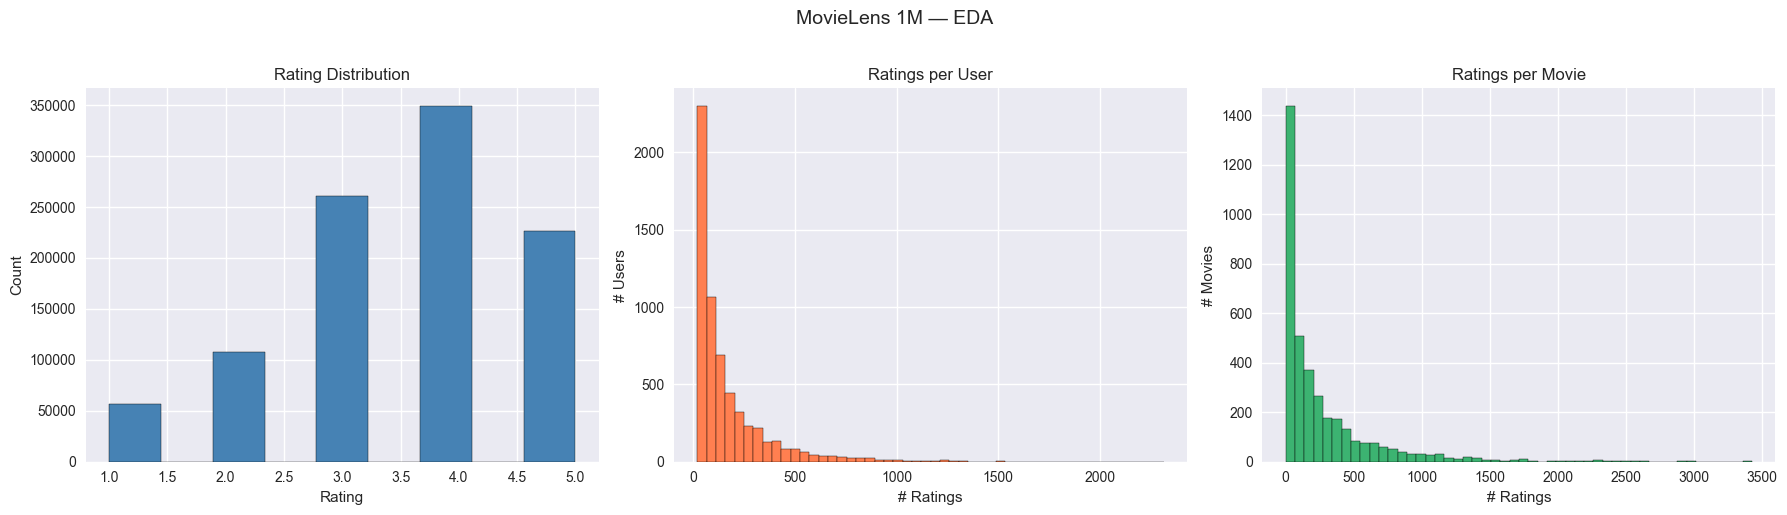

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(ratings['rating'], bins=9, edgecolor='black', color='steelblue')
axes[0].set_title('Rating Distribution'); axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')

user_counts = ratings['user_id'].value_counts()
axes[1].hist(user_counts, bins=50, edgecolor='black', color='coral')
axes[1].set_title('Ratings per User'); axes[1].set_xlabel('# Ratings'); axes[1].set_ylabel('# Users')

movie_counts = ratings['movie_id'].value_counts()
axes[2].hist(movie_counts, bins=50, edgecolor='black', color='mediumseagreen')
axes[2].set_title('Ratings per Movie'); axes[2].set_xlabel('# Ratings'); axes[2].set_ylabel('# Movies')

plt.suptitle('MovieLens 1M — EDA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
print('\n=== Top 10 Most-Rated Movies ===')
top10 = movie_counts.head(10).reset_index()
top10.columns = ['movie_id', 'rating_count']
top10 = top10.merge(movies[['movie_id','title']], on='movie_id')
display(top10[['title','rating_count']])


=== Top 10 Most-Rated Movies ===


,title,rating_count
0,American Beauty (1999),3428
1,Star Wars: Episode IV - A New Hope (1977),2991
2,Star Wars: Episode V - The Empire Strikes Back...,2990
3,Star Wars: Episode VI - Return of the Jedi (1983),2883
4,Jurassic Park (1993),2672
5,Saving Private Ryan (1998),2653
6,Terminator 2: Judgment Day (1991),2649
7,"Matrix, The (1999)",2590
8,Back to the Future (1985),2583
9,"Silence of the Lambs, The (1991)",2578


# 4. Build Surprise Dataset

In [6]:
# MovieLens 1M uses explicit integer ratings on a 1–5 scale
reader = Reader(rating_scale=(1, 5))
data   = Dataset.load_from_df(ratings[['user_id','movie_id','rating']], reader)
print(' Surprise dataset ready')

 Surprise dataset ready


# 5. Train / Test Split

In [7]:
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print(f' Trainset : {trainset.n_ratings:,} ratings')
print(f' Testset  : {len(testset):,} ratings')

 Trainset : 800,167 ratings
 Testset  : 200,042 ratings


# 6. Model 1: BaselineOnly (ALS bias optimisation)

> **Concept:**  
> Prediction formula: `r̂_ui = μ + b_u + b_i`  
> - **μ** = global mean rating  
> - **b_u** = user bias (e.g. a harsh rater always rates lower)  
> - **b_i** = item bias (e.g. a popular movie consistently rates higher)  
>  
> The biases are optimised using **Alternating Least Squares (ALS)**, so the output
> prints *"Estimating biases using als..."* — hence the name in class.  
> **This is NOT full matrix-factorisation ALS (like Spark ALS or SVD).**  
> It is a bias-only baseline model with an ALS solver inside.

In [8]:
bsl_options = {
    'method'  : 'als',   # ALS optimizer for bias estimation
    'n_epochs': 5,       # ALS iterations
    'reg_u'   : 12,      # regularisation for user bias
    'reg_i'   : 5        # regularisation for item bias
}

baseline_als = BaselineOnly(bsl_options=bsl_options)

print('=== BaselineOnly (ALS bias optimisation) — 5-fold CV ===')
cv_baseline = cross_validate(baseline_als, data, cv=5, verbose=True, measures=['mae','rmse'])

baseline_rmse = cv_baseline['test_rmse'].mean()
baseline_mae  = cv_baseline['test_mae'].mean()
print(f'\n  Mean RMSE : {baseline_rmse:.4f}')
print(f'  Mean MAE  : {baseline_mae:.4f}')

=== BaselineOnly (ALS bias optimisation) — 5-fold CV ===
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Evaluating MAE, RMSE of algorithm BaselineOnly on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.7199  0.7172  0.7179  0.7181  0.7187  0.7184  0.0009  
RMSE (testset)    0.9090  0.9072  0.9072  0.9072  0.9087  0.9079  0.0008  
Fit time          1.56    1.92    1.96    2.15    1.78    1.87    0.20    
Test time         1.19    1.07    0.93    1.52    0.83    1.11    0.24    

  Mean RMSE : 0.9079
  Mean MAE  : 0.7184


# 7. Model 2: SVD Baseline (Untuned)

In [9]:
# SVD decomposes R ≈ U · Σ · Vᵀ
# It learns latent factors for users AND items — much richer than BaselineOnly
svd_default = SVD(random_state=42)

print('=== SVD Default — 5-fold CV ===')
cv_svd = cross_validate(svd_default, data, cv=5, verbose=True, measures=['mae','rmse'])

svd_default_rmse = cv_svd['test_rmse'].mean()
svd_default_mae  = cv_svd['test_mae'].mean()
print(f'\n  Mean RMSE : {svd_default_rmse:.4f}')
print(f'  Mean MAE  : {svd_default_mae:.4f}')

=== SVD Default — 5-fold CV ===
Evaluating MAE, RMSE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.6856  0.6849  0.6872  0.6839  0.6866  0.6856  0.0012  
RMSE (testset)    0.8739  0.8722  0.8752  0.8709  0.8749  0.8734  0.0016  
Fit time          10.68   9.40    12.49   9.30    8.68    10.11   1.36    
Test time         1.84    2.02    1.73    1.43    1.33    1.67    0.26    

  Mean RMSE : 0.8734
  Mean MAE  : 0.6856


# 8. Model 3: SVD Tuned (GridSearchCV)

In [10]:
param_grid = {
    'n_factors': [50, 100],     # number of latent factors
    'n_epochs' : [10, 20],      # training iterations
    'lr_all'   : [0.005, 0.01], # learning rate
    'reg_all'  : [0.02, 0.1]    # L2 regularisation
}

print('=== SVD GridSearchCV (16 combos × 3 folds) — may take a few minutes ===')
gs = GridSearchCV(SVD, param_grid, measures=['rmse','mae'], cv=3, n_jobs=-1)
gs.fit(data)

best_params = gs.best_params['rmse']
print(f'\n Best RMSE   : {gs.best_score["rmse"]:.4f}')
print(f' Best MAE    : {gs.best_score["mae"]:.4f}')
print(f' Best params : {best_params}')

=== SVD GridSearchCV (16 combos × 3 folds) — may take a few minutes ===

 Best RMSE   : 0.8823
 Best MAE    : 0.6941
 Best params : {'n_factors': 50, 'n_epochs': 10, 'lr_all': 0.01, 'reg_all': 0.02}


In [11]:
# Train final model on full trainset with best params
best_svd = SVD(
    n_factors = best_params['n_factors'],
    n_epochs  = best_params['n_epochs'],
    lr_all    = best_params['lr_all'],
    reg_all   = best_params['reg_all'],
    random_state=42
)
best_svd.fit(trainset)

predictions   = best_svd.test(testset)
svd_tuned_rmse = accuracy.rmse(predictions)
svd_tuned_mae  = accuracy.mae(predictions)
print(f'\nFinal Test RMSE : {svd_tuned_rmse:.4f}')
print(f'Final Test MAE  : {svd_tuned_mae:.4f}')

RMSE: 0.8709
MAE:  0.6845

Final Test RMSE : 0.8709
Final Test MAE  : 0.6845


# 9. Model Comparison

,Model,RMSE,MAE
0,BaselineOnly (ALS bias),0.9079,0.7184
1,SVD Default,0.8734,0.6856
2,SVD Tuned (GridSearchCV),0.8709,0.6845


C:\Users\yonat\AppData\Local\Temp\ipykernel_100\688880915.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison['Model'], rotation=12, ha='right')
C:\Users\yonat\AppData\Local\Temp\ipykernel_100\688880915.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison['Model'], rotation=12, ha='right')


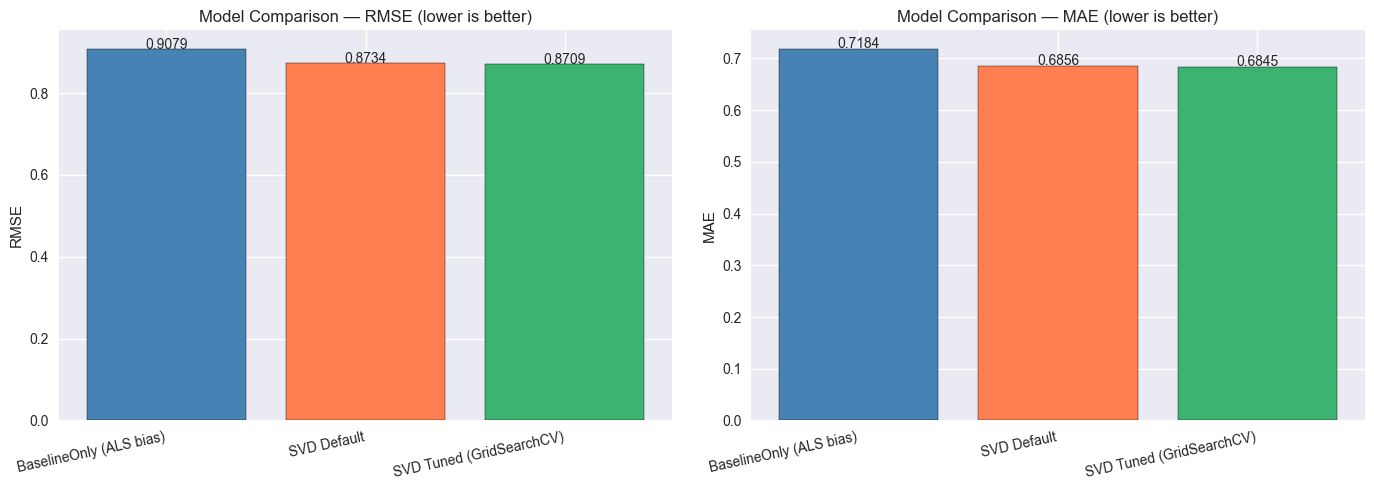

🏆 Best model: SVD Tuned (GridSearchCV)


In [ ]:
comparison = pd.DataFrame({
    'Model': ['BaselineOnly (ALS bias)', 'SVD Default', 'SVD Tuned (GridSearchCV)'],
    'RMSE' : [round(baseline_rmse,4), round(svd_default_rmse,4), round(svd_tuned_rmse,4)],
    'MAE'  : [round(baseline_mae,4),  round(svd_default_mae,4),  round(svd_tuned_mae,4)]
})
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue','coral','mediumseagreen']

for ax, metric in zip(axes, ['RMSE','MAE']):
    bars = ax.bar(comparison['Model'], comparison[metric], color=colors, edgecolor='black')
    ax.set_title(f'Model Comparison — {metric} (lower is better)')
    ax.set_ylabel(metric)
    ax.set_xticklabels(comparison['Model'], rotation=12, ha='right')
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

best = comparison.loc[comparison['RMSE'].idxmin(),'Model']
print(f'🏆 Best model: {best}')

# 10. Item-Based Movie Similarity

> SVD learns a latent vector **q_i** for every item (movie).  
> We compute **cosine similarity** between those vectors to find movies  
> that occupy a similar region in latent space — these are the 'similar movies'.

In [13]:
# Map Surprise inner IDs → raw movie_ids
inner_ids    = list(trainset.all_items())
raw_ids      = [trainset.to_raw_iid(i) for i in inner_ids]
item_factors = best_svd.qi          # shape (n_items, n_factors)

item_sim_matrix = cosine_similarity(item_factors)
item_sim_df     = pd.DataFrame(item_sim_matrix, index=raw_ids, columns=raw_ids)
movie_lookup    = movies.set_index('movie_id')['title'].to_dict()

print(f'✓ Similarity matrix shape: {item_sim_df.shape}')

def get_similar_movies(movie_title, n=10):
    match = movies[movies['title'].str.contains(movie_title, case=False, na=False)]
    if match.empty:
        print(f'❌ "{movie_title}" not found'); return None
    movie_id = match.iloc[0]['movie_id']
    title    = match.iloc[0]['title']
    if movie_id not in item_sim_df.index:
        print('Movie not in similarity matrix (not enough ratings).'); return None
    scores = item_sim_df[movie_id].sort_values(ascending=False)
    scores = scores[scores.index != movie_id].head(n)
    result = pd.DataFrame({'movie_id': scores.index, 'similarity': scores.values})
    result['title'] = result['movie_id'].map(movie_lookup)
    result = result[['title','similarity']].reset_index(drop=True)
    result.index += 1
    print(f'Top {n} movies similar to: {title}')
    return result

display(get_similar_movies('Toy Story', n=10))

✓ Similarity matrix shape: (3675, 3675)
Top 10 movies similar to: Toy Story (1995)


,title,similarity
1,Toy Story 2 (1999),0.813284
2,Beauty and the Beast (1991),0.650044
3,"Bug's Life, A (1998)",0.649245
4,Aladdin (1992),0.646786
5,Babe (1995),0.596547
6,Lady and the Tramp (1955),0.584347
7,"Lion King, The (1994)",0.571273
8,Peter Pan (1953),0.549302
9,"Rescuers Down Under, The (1990)",0.545447
10,"Little Mermaid, The (1989)",0.544911


# 11 Save Models with Joblib

In [14]:
# Retrain BaselineOnly on full dataset before saving
'''full_trainset = data.build_full_trainset()
baseline_full = BaselineOnly(bsl_options=bsl_options)
baseline_full.fit(full_trainset)

joblib.dump(best_svd,         'model/svd_model.pkl')       ; print('✓ model/svd_model.pkl')
joblib.dump(baseline_full,    'model/baseline_als.pkl')    ; print('✓ model/baseline_als.pkl')
joblib.dump(item_sim_df,      'model/item_sim_df.pkl')     ; print('✓ model/item_sim_df.pkl')
joblib.dump(movie_lookup,     'model/movie_lookup.pkl')    ; print('✓ model/movie_lookup.pkl')
joblib.dump(best_params,      'model/best_svd_params.pkl') ; print('✓ model/best_svd_params.pkl')
comparison.to_csv('model/model_comparison.csv', index=False); print('✓ model/model_comparison.csv')
print('\n🎉 All artefacts saved to model/')'''

"full_trainset = data.build_full_trainset()\nbaseline_full = BaselineOnly(bsl_options=bsl_options)\nbaseline_full.fit(full_trainset)\n\njoblib.dump(best_svd,         'model/svd_model.pkl')       ; print('✓ model/svd_model.pkl')\njoblib.dump(baseline_full,    'model/baseline_als.pkl')    ; print('✓ model/baseline_als.pkl')\njoblib.dump(item_sim_df,      'model/item_sim_df.pkl')     ; print('✓ model/item_sim_df.pkl')\njoblib.dump(movie_lookup,     'model/movie_lookup.pkl')    ; print('✓ model/movie_lookup.pkl')\njoblib.dump(best_params,      'model/best_svd_params.pkl') ; print('✓ model/best_svd_params.pkl')\ncomparison.to_csv('model/model_comparison.csv', index=False); print('✓ model/model_comparison.csv')\nprint('\n🎉 All artefacts saved to model/')"

# 12. Conclusion & Next Steps

=== Project Summary ===

Dataset  : 1,000,209 ratings | 6,040 users | 3,706 movies

Sparsity : 95.53%

Limitations:
- Cold-start: new users/movies have no history
- Only explicit ratings used — no metadata or tags
- Temporal dynamics not modelled

Next Steps:
  1. Add KNNBasic (neighbourhood-based CF)
  2. Hybrid model: combine SVD + content (genres)
  3. Implicit feedback with LightFM or implicit library